# Intro PyTorch: regresión lineal desde cero (réplica)

Objetivo: reconstruir el notebook original pieza por pieza, verificando formas y valores en cada paso.

Plan:
1. Datos sintéticos
2. Forward como función suelta
3. Pérdida y gradiente a mano
4. Un paso de SGD manual y bucle simple
5. Clases `SGD` y `LinearRegression`
6. Minibatches y validación (`TensorDataset`, `DataLoader`)
7. Bucle de entrenamiento completo y gráfica

## 1. Datos sintéticos

**Qué espero:** `X` de forma `(1000, 2)` y `y` de forma `(1000, 1)`, con `y ≈ X @ true_w + true_b`.

Revisar: `.shape`, primeras filas, y la diferencia `y - (X @ w + b)` (debería ser solo ruido).

In [1]:
import torch

# TODO: definir synthetic_regression_data(w, b, num_samples=1000)

# Crear datos sintéticos para probar la infraestructura: 

def synthetic_regression_data(w, b, num_samples = 1000):
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1,1) + b
    y += torch.randn_like(y) * 0.01
    return X, y

    


In [2]:
# TODO: generar X, y con true_w = [2.0, -3.4], true_b = 4.2 e inspeccionar shapes y valores
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)

In [3]:
X.shape


torch.Size([1000, 2])

In [4]:
y.shape

torch.Size([1000, 1])

## 2. Forward como función suelta

**Qué espero:** con `w` de forma `(2, 1)` y `b` de forma `(1,)`, `X @ w + b` da `(1000, 1)`. Observar cómo el broadcasting expande `b`.

In [5]:
# TODO: inicializar w (torch.normal) y b (torch.zeros) con requires_grad=True
# TODO: calcular y_hat = X @ w + b y revisar shapes
import torch.nn as nn

w = nn.Parameter(torch.normal(0.0, 0.01, size=(2, 1), requires_grad=True)) ## inicializamos en 0 porque es una regresión lineal y la función de perdida es convexa, entonces siempre ecncontraremos el minimo global)
b = nn.Parameter(torch.zeros(1))

def forward(X, w, b):
    """ Calcula la estimación y_hat dados los paramétros actuales y X"""
    return torch.matmul(X, w) + b

y_hat = forward(X, w, b)



In [6]:
print(w.shape)

print(b.shape)

print(X.shape)

print(y_hat.shape)

torch.Size([2, 1])
torch.Size([1])
torch.Size([1000, 2])
torch.Size([1000, 1])


In [7]:
y_hat

tensor([[-2.6394e-02],
        [-1.8846e-02],
        [ 1.7642e-02],
        [-2.3982e-02],
        [-2.9807e-02],
        [ 1.4799e-02],
        [-8.8667e-03],
        [-1.2908e-02],
        [-3.5835e-02],
        [-1.4571e-02],
        [-4.2790e-03],
        [ 1.7241e-03],
        [-1.2199e-02],
        [-1.2834e-02],
        [ 1.2494e-02],
        [ 1.7324e-02],
        [ 1.0106e-02],
        [ 2.8794e-02],
        [-2.6031e-02],
        [ 2.5559e-02],
        [ 1.1178e-02],
        [ 8.7720e-03],
        [ 2.9463e-02],
        [-9.3111e-03],
        [-1.7748e-03],
        [ 1.7089e-03],
        [-7.8483e-03],
        [-3.5455e-03],
        [-4.3257e-03],
        [-1.5068e-02],
        [-1.8631e-02],
        [-2.4642e-02],
        [-7.4840e-03],
        [ 2.6360e-02],
        [ 2.4057e-02],
        [ 5.5607e-03],
        [-1.0606e-02],
        [-1.1915e-02],
        [-1.3235e-02],
        [-2.5207e-02],
        [ 1.4285e-02],
        [-3.4900e-03],
        [ 7.3383e-03],
        [-1

## 3. Pérdida y gradiente a mano

**Qué espero:** `loss.backward()` llena `w.grad` (forma `(2, 1)`) y `b.grad` (forma `(1,)`).

Pregunta: ¿por qué el gradiente apunta hacia donde la pérdida *sube*, y por eso restamos?

In [8]:
# TODO: loss = ((y_hat - y) ** 2 / 2).mean()
# TODO: loss.backward() e inspeccionar w.grad, b.grad

def loss(y_hat, y):
    """Calcula la pérdida de regresión lineal
    y devuelve el valor medio sobre el minibatch.
    """
    # 1) Error al cuadrado, escalado por 1/2
    l = (y_hat - y) ** 2 / 2
    # 2) Promedio sobre todas las muestras
    return l.mean()

loss_c = loss(y_hat, y)

loss_c.backward()



In [9]:
loss_c.item()

16.340932846069336

In [10]:
b.grad

tensor([-4.1942])

## 4. Un paso de SGD manual y bucle simple

**Qué espero:** tras `w.data -= lr * w.grad`, la pérdida baja. Repetir en un bucle con todos los datos (sin `DataLoader`) y ver la pérdida decrecer.

Recordar limpiar los gradientes en cada iteración.

In [11]:
# TODO: un solo paso de SGD y recalcular la pérdida

lr = 0.03

w.data -= lr * w.grad

b.data -= lr * b.grad

y_hat = forward(X, w, b)

loss_c4 = loss(y_hat, y)

loss_c4.item()


15.383970260620117

In [12]:
# TODO: bucle de varias iteraciones con todos los datos, imprimiendo la pérdida

params = [w, b]

def zero_grad(params):
    """Pone en cero los gradientes acumulados."""
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

def step(params, lr):
    """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
    for p in params:
        p.data -= lr * p.grad

num_iters = 100
for i in range(num_iters):
    y_hat = forward(X, w, b)       # 1) predicción con los pesos actuales (w, b sin .data)
    loss_i = loss(y_hat, y)        # 2) pérdida -> crea un grafo nuevo
    zero_grad(params)              # 3) limpia los gradientes de la iteración anterior
    loss_i.backward()              # 4) gradientes nuevos en w.grad y b.grad
    step(params, lr)               # 5) mueve w y b en contra del gradiente
    if i % 30 == 0 or i == num_iters - 1:
        print(f"iter {i:3d} | pérdida {loss_i.item():.6f}")  # 6) monitorear

print("w aprendido:", w.data.reshape(-1))
print("b aprendido:", b.data)

    

iter   0 | pérdida 15.383970
iter  30 | pérdida 2.535316
iter  60 | pérdida 0.423647
iter  90 | pérdida 0.071731
iter  99 | pérdida 0.042214
w aprendido: tensor([ 1.9437, -3.2011])
b aprendido: tensor([4.0004])


## 5. Clases `SGD` y `LinearRegression`

Cada método es algo que ya escribiste suelto arriba:
- `SGD.step` / `SGD.zero_grad` ← pasos 3 y 4
- `LinearRegression.forward` ← paso 2
- `LinearRegression.loss` ← paso 3
- `LinearRegression.configure_optimizers` devuelve un `SGD`

In [19]:
# TODO: class SGD

class SGD:
    """Descenso de gradiente estocástico por minibatches."""
    def __init__(self, params, lr):
        # params: iterable de nn.Parameter
        self.params = list(params)
        self.lr = lr

    def step(self):
        """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
        for p in self.params:
            # p.grad es el gradiente calculado en backward()
            p.data -= self.lr * p.grad

    def zero_grad(self):
        """Pone a cero todos los gradientes para la siguiente iteración."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

In [20]:
import torch.nn as nn

# TODO: class LinearRegression(nn.Module)

class LinearRegression(nn.Module):
    """Modelo de regresión lineal implementado desde cero en PyTorch"""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super(LinearRegression, self).__init__()
        # Guardamos los hiperparámetros “a mano”, lo que le pasamos se asigna a la instancia en particular
        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma
        # Parámetros del modelo: pesos y sesgo
        # nn.Parameter indica a PyTorch que debe calcular gradientes sobre este tensor
        self.w = nn.Parameter(
            torch.normal(0.0, sigma, size=(num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )
    
    def forward(self, X):
        """ Calcula la estimación y_hat dados los paramétros actuales y X"""
        return torch.matmul(X, self.w) + self.b
    
    def loss(self, y_hat, y):
        """Calcula la pérdida de regresión lineal
        y devuelve el valor medio sobre el minibatch.
        """
        # 1) Error al cuadrado, escalado por 1/2
        l = (y_hat - y) ** 2 / 2
        # 2) Promedio sobre todas las muestras
        return l.mean()
    
    def configure_optimizers(self):
        """
        Crea y devuelve el optimizador SGD configurado con nuestros parámetros.
        """
        # Pasamos los parámetros w y b al optimizador y la lr
        return SGD([self.w, self.b], self.lr)

## 6. Minibatches y validación

**Qué espero:** `train_dataset` con 800 ejemplos y `val_dataset` con 200. Un minibatch de `next(iter(train_loader))` tiene `Xb` de `(32, 2)` y `yb` de `(32, 1)`.

In [42]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# TODO: TensorDataset, random_split 80/20, DataLoaders (batch_size=32, shuffle solo en train)

#Paso 1 
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)

#Paso 2 

dataset = TensorDataset (X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#Paso 3 - Data loader (esto sirve para crear batches con 32 ejemplos cada uno)

batch_size = 32 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #aquí shuffle es True para que 
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) #aquí es False porque no queremos aleatoriedad en las muestras de validación



In [43]:
print(len(train_dataset))
print(len(val_dataset))

800
200


In [48]:
# TODO: inspeccionar un minibatch con next(iter(train_loader))
next(iter(train_loader))

[tensor([[-1.0765,  0.0304],
         [-1.0545, -0.2951],
         [-2.2950,  0.1076],
         [ 0.2603,  0.4392],
         [ 1.7213,  0.9012],
         [-0.5217,  1.2500],
         [ 2.6303, -0.3470],
         [ 0.6674,  1.4104],
         [-0.2237,  0.7447],
         [ 0.0567, -1.2576],
         [ 0.6120, -1.3976],
         [-0.0293, -0.7918],
         [-1.4381,  1.9387],
         [-0.4016, -0.0664],
         [-0.7765,  0.1297],
         [ 0.7187, -0.4357],
         [-0.5150,  2.5949],
         [ 0.4283, -0.2929],
         [ 1.0405,  0.7566],
         [-0.1461,  1.4804],
         [-0.6750, -0.8756],
         [ 0.1874, -0.4036],
         [ 0.8106, -0.4091],
         [-0.7681, -0.6630],
         [ 0.8121, -0.1014],
         [ 1.5942, -0.0809],
         [-0.3315, -0.1276],
         [ 0.3890,  1.0968],
         [-1.8780,  0.6315],
         [ 0.3221, -1.1084],
         [ 1.6180, -0.4319],
         [-0.3234, -1.8032]]),
 tensor([[ 1.9287],
         [ 3.0863],
         [-0.7518],
         [

## 7. Entrenamiento completo y gráfica

**Qué espero:** ambas pérdidas bajan hacia ~0 (el ruido es 0.01, así que el mínimo teórico ronda 5e-5) y `est_w`, `est_b` quedan muy cerca de los valores verdaderos.

In [63]:
# TODO: instanciar modelo y optimizador
# TODO: bucle por épocas (fase train + fase validación con torch.no_grad())

model = LinearRegression(num_inputs = 2, lr = 0.03)
optim = model.configure_optimizers()

num_epochs = 10

# Listas para almacenar la pérdida media de cada epoch
train_losses, val_losses = [], []


In [64]:
#Entrenamiento 

for epoch in range(1, num_epochs + 1): #esto lo hacemos para que la epoch 1 diga 1 tal cual
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader: #aqui Xb significa las X dento del minibatch y lo mismo para las yb
        loss = model.loss(model(Xb), yb)
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]
    train_losses.append(total_train/count_train) #guardamos la pérdida media por ejemplo
    
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv) #esto "model(Xv)"" es lo mismo que calcular y_hat = model(Xv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
    val_losses.append(total_val / count_val)

In [65]:
train_losses

[8.784940509796142,
 1.9242740774154663,
 0.42374048590660096,
 0.09396023586392403,
 0.021047655083239077,
 0.004773216429166496,
 0.0011214315355755388,
 0.00029571951599791644,
 0.00010839770824532025,
 6.529232909088024e-05]

In [67]:
val_losses

[3.979388313293457,
 0.8697782015800476,
 0.19125637888908387,
 0.0422622013092041,
 0.009390654638409615,
 0.0021122555155307053,
 0.0004940110107418149,
 0.0001421188173117116,
 6.62419103900902e-05,
 5.15490846009925e-05]

Error en w: tensor([ 0.0008, -0.0024])
Error en b: tensor([0.0017])


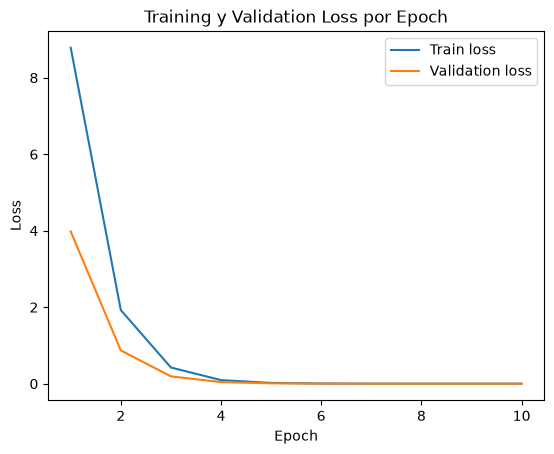

In [68]:
import matplotlib.pyplot as plt

# TODO: error en w y b, y gráfica de train/val loss por época

with torch.no_grad():
    est_w = model.w.reshape(true_w.shape)
    est_b = model.b
    print('Error en w:', true_w - est_w)
    print('Error en b:', true_b - est_b)

# 8) Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()


In [ ]:
import torch

w_history_t = torch.stack(w_historico)  # forma (num_epochs, num_inputs)
num_inputs = w_history_t.shape[1]

# líneas de referencia con los valores verdaderos

for i in range(num_inputs):
    color =  f"C{i}"
    plt.plot(range(0, num_epochs + 1), w_history_t[:, i], color = color, label = f"w{i+1} estimado")
    plt.axhline(true_w[i].item(), color = color, linestyle = "--", alpha = 0.5)

b_color = f"C{num_inputs}"
plt.plot(range(0, num_epochs +1), b_historico, color = b_color, label = "b estimado")
plt.axhline(true_b, color = b_color, linestyle = "--", alpha = 0.5)

plt.xlabel("Época")
plt.ylabel("Valor del parámetro")
plt.legend()
plt.title("Evolución de w y b por época")
plt.show()

## 8. Experimentos (opcional)

Rompe cosas a propósito y anota qué pasa:
- Quitar `zero_grad()`
- `lr = 1.0` y `lr = 0.0001`
- Quitar `shuffle=True`